In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

# ---------- 1. LOAD FILES ----------
ho_file = "data/LTE Cell Relations KE.csv"
kpi_file = "data/2025-09_RAN_data_LTE_800_KE(in).csv"

df_ho = pd.read_csv(ho_file)
df_kpi = pd.read_csv(kpi_file)

# ---------- 2. TIME FEATURES ----------

df_kpi["start_time"] = pd.to_datetime(df_kpi["start_time"])

df_kpi["hour"] = df_kpi["start_time"].dt.hour
df_kpi["dayofweek"] = df_kpi["start_time"].dt.dayofweek

df_kpi["hour_sin"] = np.sin(2 * np.pi * df_kpi["hour"] / 24)
df_kpi["hour_cos"] = np.cos(2 * np.pi * df_kpi["hour"] / 24)

df_kpi["dow_sin"] = np.sin(2 * np.pi * df_kpi["dayofweek"] / 7) # day of week
df_kpi["dow_cos"] = np.cos(2 * np.pi * df_kpi["dayofweek"] / 7)

df_kpi["is_weekend"] = (df_kpi["dayofweek"] >= 5).astype(int)

TIME_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend"]

# ---------- 4. UNIQUE CELLS ----------
node_list = df_kpi["cell"].unique().tolist()
cells_kpi = set(node_list)
print("Number of KPI cells:", len(node_list))

# ---------- 5. CLEAN HO TABLE & EDGE LIST ----------
df_ho_clean = df_ho.rename(columns={
    "CELL_NAME1": "source",
    "CELL_NAME2": "target",
    "HO Execution Successes [#]": "ho_count"
})

# Удаляем self-loops
df_ho_clean = df_ho_clean[df_ho_clean["source"] != df_ho_clean["target"]]

# Фильтр по технологии, если есть RatBandShort
if "RatBandShort.1" in df_ho_clean.columns:
    df_ho_clean = df_ho_clean[df_ho_clean["RatBandShort.1"] == "L08"]
before = len(df_ho_clean)

# REMOVE INTRA-SITE RELATIONS
if "SITE_ID1" in df_ho_clean.columns and "SITE_ID2" in df_ho_clean.columns:
    df_ho_clean = df_ho_clean[df_ho_clean["SITE_ID1"] != df_ho_clean["SITE_ID2"]]
after = len(df_ho_clean)

print("Edges before removing intra-site:", before)
print("Edges after removing intra-site :", after)
print("Removed:", before - after)

Number of KPI cells: 197
Edges before removing intra-site: 3764
Edges after removing intra-site : 3384
Removed: 380


In [2]:
# ---------- 6. BUILD CELL NEIGHBOR TABLE ----------

# Функция извлечения BS
def extract_bs(cell_name):
    return cell_name[1:6]  # TK1ALP1 -> K1ALP (под твой формат)

# Добавляем BS
df_ho_clean["bs"] = df_ho_clean["source"].apply(extract_bs)

# Группируем по клетке
neighbor_table = (
    df_ho_clean
    .groupby("source")["target"]
    .agg(list)
    .reset_index()
)

# Добавляем BS
neighbor_table["bs"] = neighbor_table["source"].apply(extract_bs)

# Убираем дубликаты соседей (на всякий)
neighbor_table["target"] = neighbor_table["target"].apply(lambda x: list(set(x)))

# Количество соседей
neighbor_table["neighbor_count"] = neighbor_table["target"].apply(len)

# Переименование колонок
neighbor_table = neighbor_table.rename(columns={
    "source": "cell",
    "target": "neighbors"
})

# Сортировка (по желанию)
neighbor_table = neighbor_table.sort_values(by="neighbor_count", ascending=False)

# ---------- 7. SAVE ----------
neighbor_table.to_csv("cell_neighbor_table.csv", index=False)

# NEIGHBOR MEDIAN CORRELATION ANALYSIS:
Source Load ("4g_usage_%_lte_800") → Median Neighbor Quality

### Hypoteza: Ak je bunka silne zaťažená (4g_usage_%_lte_800), potom priemerná kvalita jej susedných buniek (CQI, MIMO rank) je nižšia.

Analyzing impact of 4g_usage_%_lte_800 on medeian neighbor quality: ['cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800', 'mimo_rank_dl_4g_lte_800']
Valid cells for analysis: 192

CORRELATION: Source Load → Median Neighbor Quality
4g_usage_%_lte_800 → median cqi_tr1_4g_lte_800:
  Pearson r = -0.0185, p-value = 0.7994
4g_usage_%_lte_800 → median cqi_tr2_4g_lte_800:
  Pearson r = 0.0601, p-value = 0.4075
4g_usage_%_lte_800 → median mimo_rank_dl_4g_lte_800:
  Pearson r = 0.0024, p-value = 0.9740


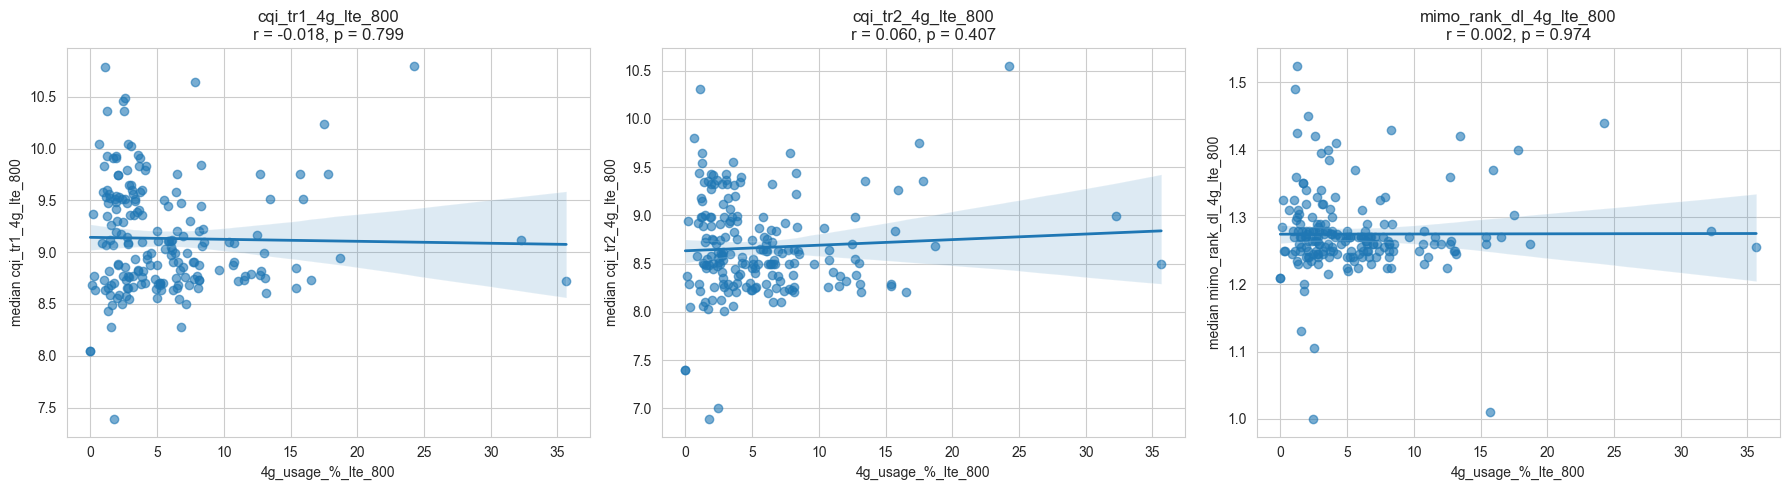

In [3]:
# DEFINITIONS
SOURCE_METRIC = "4g_usage_%_lte_800"

TARGET_METRICS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

print("Analyzing impact of", SOURCE_METRIC, "on medeian neighbor quality:", TARGET_METRICS)

# 1. KPI MEDIANS PER CELL - для каждой клетки: берёт ВСЕ её значения по времени и считает среднее
kpi_mean = df_kpi.groupby("cell")[ [SOURCE_METRIC] + TARGET_METRICS ].median()

# 2. BUILD CELL-LEVEL DATASET
records = []
for _, row in neighbor_table.iterrows():
    cell = row["cell"]
    neighbors = row["neighbors"]
    # Проверка наличия KPI у source
    if cell not in kpi_mean.index:
        continue
    source_value = kpi_mean.loc[cell, SOURCE_METRIC]
    # KPI соседей
    neighbor_kpis = []
    for n in neighbors:
        if n in kpi_mean.index:
            neighbor_kpis.append(kpi_mean.loc[n, TARGET_METRICS])

    # если нет валидных соседей — пропускаем
    if len(neighbor_kpis) == 0:
        continue

    neighbor_df = pd.DataFrame(neighbor_kpis)

    record = {
        "cell": cell,
        "source_" + SOURCE_METRIC: source_value,
        "neighbor_count": len(neighbor_kpis)
    }

    # среднее качество соседей
    for metric in TARGET_METRICS:
        record["neighbor_mean_" + metric] = neighbor_df[metric].median()

    records.append(record)

neighbor_analysis_usage = pd.DataFrame(records)
print("Valid cells for analysis:", len(neighbor_analysis_usage))


# 3. CORRELATION + PLOTS
print("\n" + "="*60)
print("CORRELATION: Source Load → Median Neighbor Quality")
print("="*60)

# создаём 1 строку, 3 графика
fig, axes = plt.subplots(1, len(TARGET_METRICS), figsize=(18, 5))

for i, metric in enumerate(TARGET_METRICS):
    x = neighbor_analysis_usage["source_" + SOURCE_METRIC]
    y = neighbor_analysis_usage["neighbor_mean_" + metric]

    corr_val, p_val = pearsonr(x, y)
    print(f"{SOURCE_METRIC} → median {metric}:")
    print(f"  Pearson r = {corr_val:.4f}, p-value = {p_val:.4f}")

    # PLOT
    sns.regplot(
        x=x,
        y=y,
        ax=axes[i],
        scatter_kws={"alpha": 0.6},
        line_kws={"linewidth": 2}
    )
    axes[i].set_xlabel(SOURCE_METRIC)
    axes[i].set_ylabel("median " + metric)
    axes[i].set_title(
        f"{metric}\n"
        f"r = {corr_val:.3f}, p = {p_val:.3f}"
    )
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Kód vypočíta priemerné zaťaženie pre každú bunku a potom ho porovná s priemernou kvalitou susedných buniek (CQI a MIMO). Následne vykreslí grafy a vypočíta korelácie, aby pochopil, či zaťaženie jednej bunky ovplyvňuje kvalitu jej okolia.

Vo všetkých troch grafoch sú bodky náhodne rozptýlené a čiary sú takmer vodorovné, čo naznačuje, že neexistuje žiadny vzťah medzi zaťažením a kvalitou susedných buniek. Hodnoty korelácie (r ≈ 0) a veľmi veľké p-hodnoty (> 0,4) potvrdzujú, že vzťah je štatisticky nevýznamný. Zaťaženie bunky v týchto údajoch prakticky nemá vplyv na CQI a MIMO jej susedov.

## Vizualizacia -- Usage

BOXPLOT: Usage % → Median Neighbor Quality


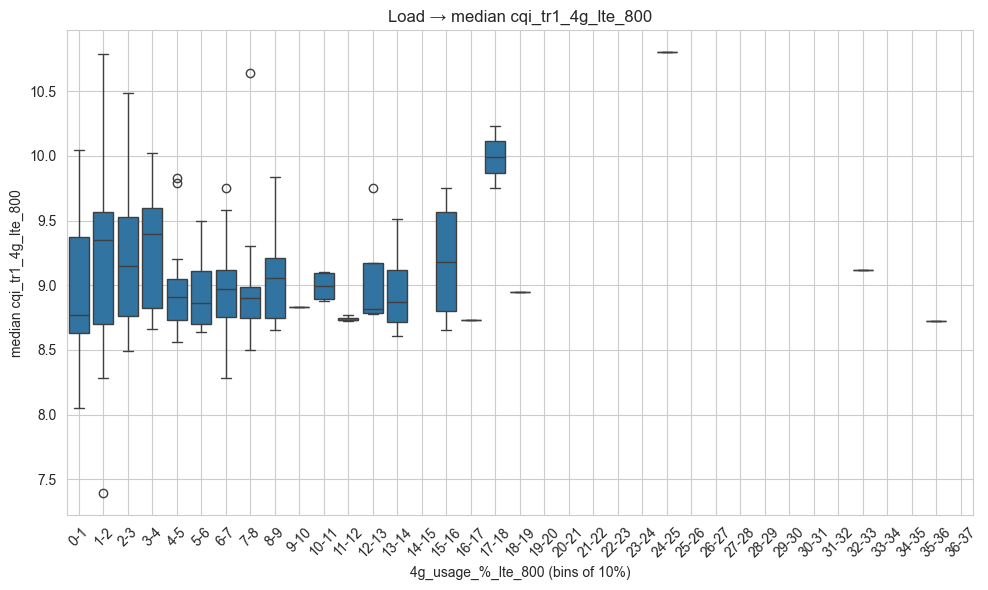

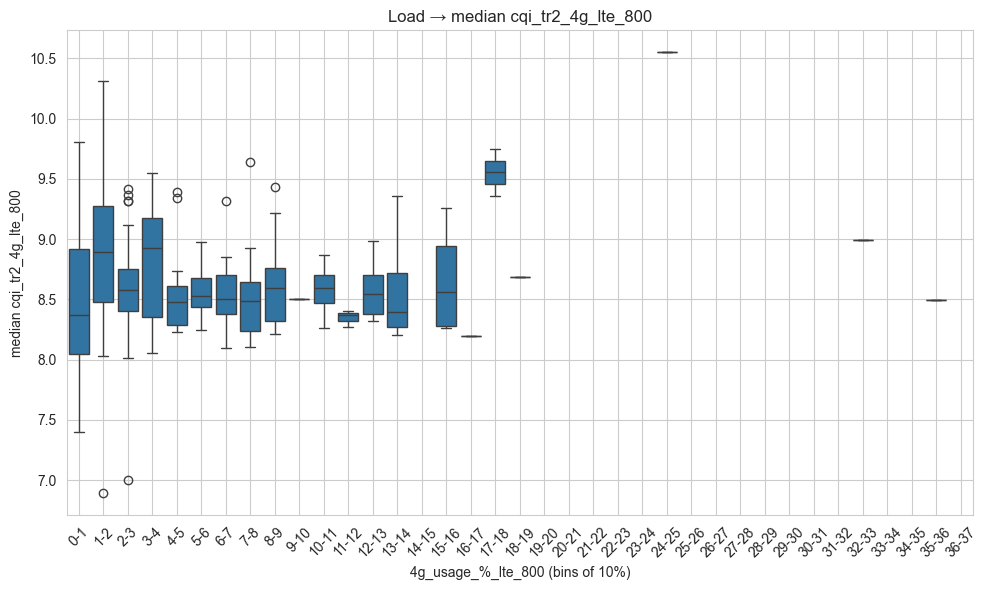

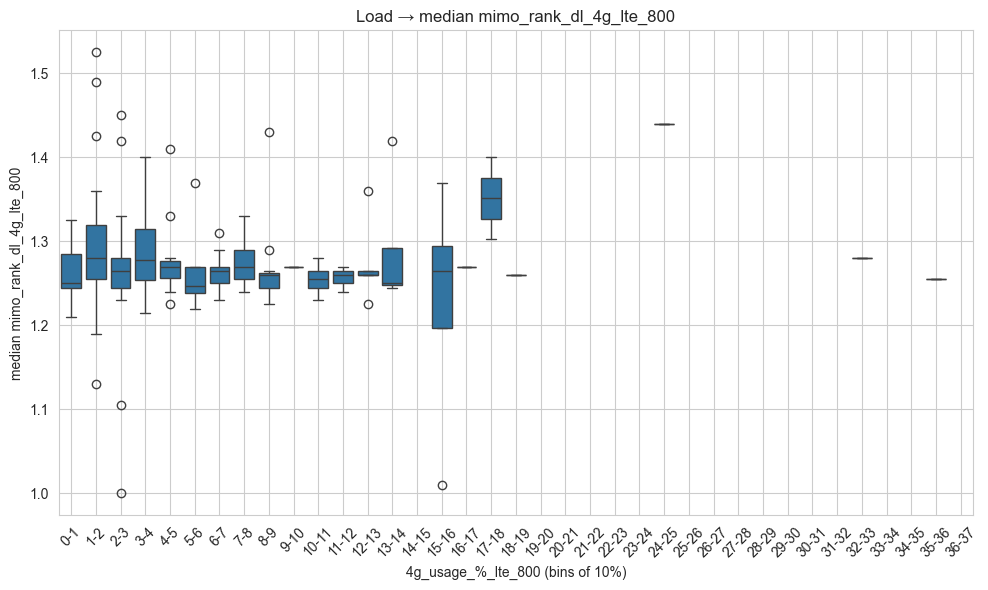

In [4]:
# BOXPLOT WITH FIXED BINS (LOAD-BASED)
print("BOXPLOT: Usage % → Median Neighbor Quality")

# Ограничение по X (нагрузка в %)
max_load = 37
df_plot = neighbor_analysis_usage[
    neighbor_analysis_usage["source_4g_usage_%_lte_800"] <= max_load
].copy()

# создаём бины (например шаг = 10%)
bin_size = 1
bins = np.arange(0, max_load + bin_size, bin_size)

# labels вида "0-10", "10-20", ...
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

df_plot["load_bin"] = pd.cut(
    df_plot["source_4g_usage_%_lte_800"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# PLOTS
for metric in TARGET_METRICS:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df_plot,
        x="load_bin",
        y="neighbor_mean_" + metric
    )
    plt.xlabel("4g_usage_%_lte_800 (bins of 10%)")
    plt.ylabel("median " + metric)
    plt.title(f"Load → median {metric}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Kód rozdelí zaťaženie siete (Load, v %) na malé intervaly (priehradky) a zoskupí dáta podľa týchto intervalov. Potom vykreslí boxplot pre každý interval, aby ukázal, ako sa mení kvalita susedných buniek (CQI a MIMO) pri rôznych zaťaženiach.

Celkovo je zrejmé, že so zvyšujúcim sa zaťažením kvalita (CQI) výrazne neklesá a na niektorých miestach sa dokonca mierne zvyšuje – čo znamená, že neexistuje silná korelácia. Rozptyl hodnôt (výšky políčok) je približne rovnaký, čo naznačuje stabilnú kvalitu pri rôznych úrovniach zaťaženia. Pre MIMO sú zmeny ešte menšie – je takmer nezávislá od zaťaženia a zostáva približne na rovnakej úrovni.

# NEIGHBOR STRUCTURE CORRELATION ANALYSIS:
Neighbor Count → Median Neighbor Quality

### Hypotéza: Ak má bunka veľa susedov (neighbor_count), potom priemerná kvalita jej susedných buniek (CQI, MIMO rank) je nižšia.

Analyzing impact of neighbor_count on median neighbor quality: ['cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800', 'mimo_rank_dl_4g_lte_800']
Valid cells for analysis: 192

CORRELATION: Neighbor Count → Median Neighbor Quality
neighbor_count → median cqi_tr1_4g_lte_800:
  Pearson r = -0.3665, p-value = 0.0000
neighbor_count → median cqi_tr2_4g_lte_800:
  Pearson r = -0.2467, p-value = 0.0006
neighbor_count → median mimo_rank_dl_4g_lte_800:
  Pearson r = -0.2102, p-value = 0.0034


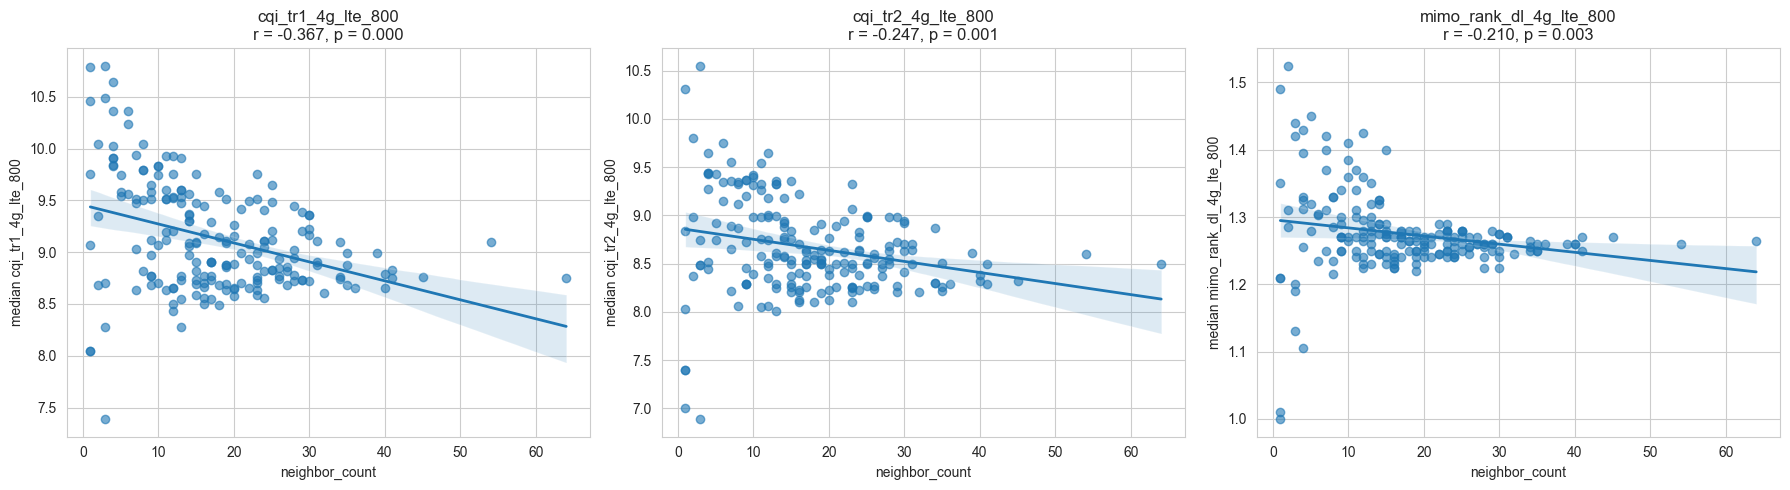

In [5]:
# DEFINITIONS
SOURCE_METRIC = "neighbor_count"

TARGET_METRICS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

print("Analyzing impact of", SOURCE_METRIC, "on median neighbor quality:", TARGET_METRICS)


# 1. KPI MEDIAN PER CELL
kpi_mean = df_kpi.groupby("cell")[TARGET_METRICS].median()


# 2. BUILD CELL-LEVEL DATASET
records = []

for _, row in neighbor_table.iterrows():
    cell = row["cell"]
    neighbors = row["neighbors"]
    neighbor_count = row["neighbor_count"]

    # KPI соседей
    neighbor_kpis = []
    for n in neighbors:
        if n in kpi_mean.index:
            neighbor_kpis.append(kpi_mean.loc[n, TARGET_METRICS])

    # если нет валидных соседей — пропускаем
    if len(neighbor_kpis) == 0:
        continue

    neighbor_df = pd.DataFrame(neighbor_kpis)

    record = {
        "cell": cell,
        "source_" + SOURCE_METRIC: neighbor_count,
        "neighbor_count": len(neighbor_kpis)
    }

    # среднее качество соседей
    for metric in TARGET_METRICS:
        record["neighbor_mean_" + metric] = neighbor_df[metric].median()

    records.append(record)

neighbor_analysis_neighbors = pd.DataFrame(records)

print("Valid cells for analysis:", len(neighbor_analysis_neighbors))


# 3. CORRELATION + PLOTS
print("\n" + "="*60)
print("CORRELATION: Neighbor Count → Median Neighbor Quality")
print("="*60)

# создаём 1 строку, 3 графика
fig, axes = plt.subplots(1, len(TARGET_METRICS), figsize=(18, 5))

for i, metric in enumerate(TARGET_METRICS):
    x = neighbor_analysis_neighbors["source_" + SOURCE_METRIC]
    y = neighbor_analysis_neighbors["neighbor_mean_" + metric]

    corr_val, p_val = pearsonr(x, y)
    print(f"{SOURCE_METRIC} → median {metric}:")
    print(f"  Pearson r = {corr_val:.4f}, p-value = {p_val:.4f}")

    # PLOT
    sns.regplot(
        x=x,
        y=y,
        ax=axes[i],
        scatter_kws={"alpha": 0.6},
        line_kws={"linewidth": 2}
    )
    axes[i].set_xlabel(SOURCE_METRIC)
    axes[i].set_ylabel("median " + metric)
    axes[i].set_title(
        f"{metric}\n"
        f"r = {corr_val:.3f}, p = {p_val:.3f}"
    )
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Existuje štatisticky významná negatívna korelácia medzi počtom susedov bunky a kvalitou jej susedných buniek (CQI aj MIMO rank).
To znamená, že bunky s väčším počtom susedov majú tendenciu mať horšiu priemernú kvalitu v okolí.

## VISUALIZATION -- Neighbor Count

BOXPLOT: Neighbor Count → Median Neighbor Quality


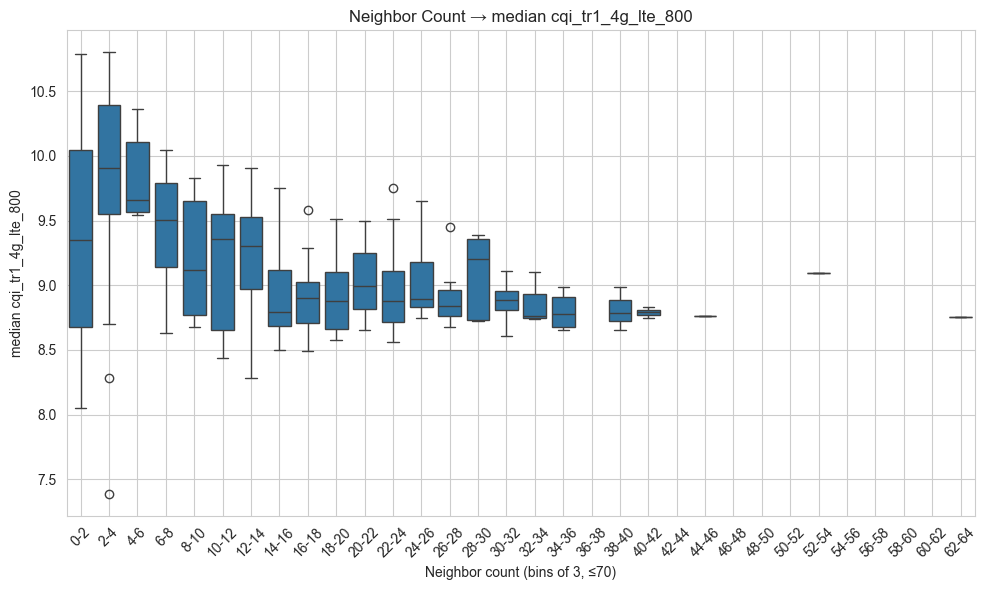

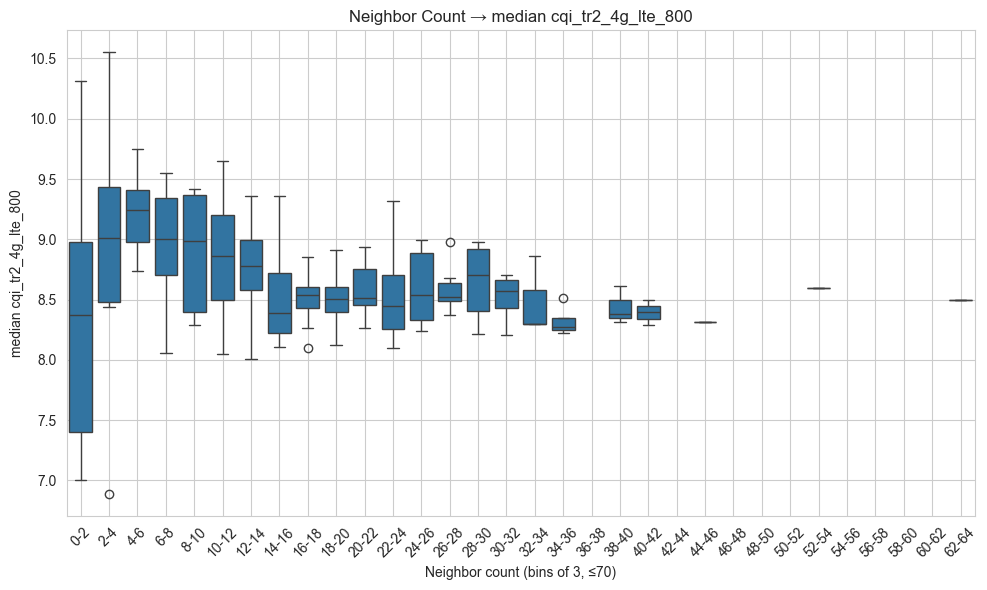

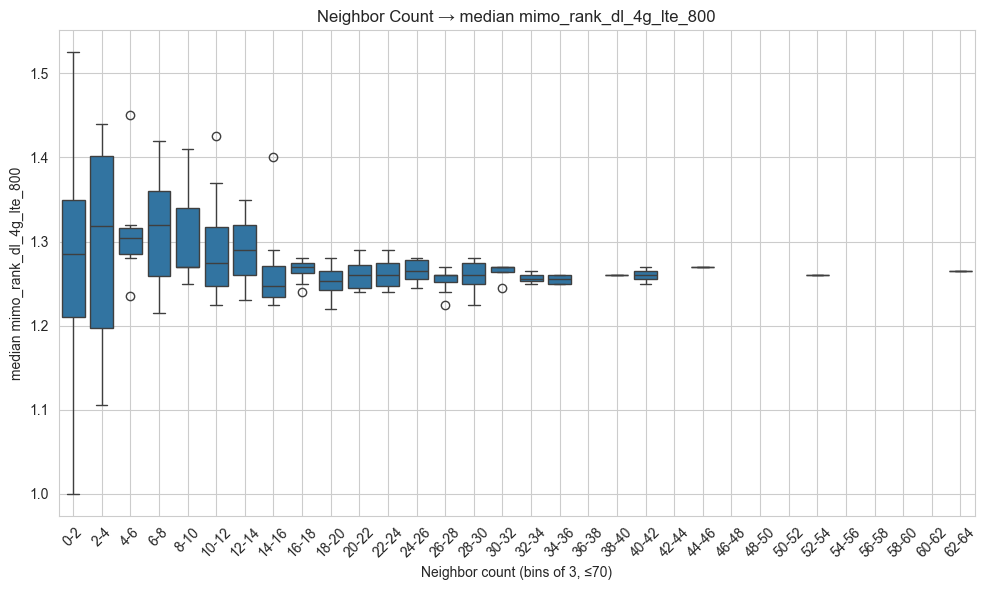

In [6]:
# BOXPLOT WITH FIXED BINS
print("BOXPLOT: Neighbor Count → Median Neighbor Quality")

# Ограничение по X
max_neighbors = 64

df_plot = neighbor_analysis_neighbors[
    neighbor_analysis_neighbors["neighbor_count"] <= max_neighbors
].copy()

# создаём бины (шаг = 3)
bin_size = 2
bins = np.arange(0, max_neighbors + bin_size, bin_size)

# labels вида "0-3", "3-6", ...
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

# используем именно neighbor_count
df_plot["neighbor_bin"] = pd.cut(
    df_plot["neighbor_count"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# PLOTS
for metric in TARGET_METRICS:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df_plot,
        x="neighbor_bin",
        y="neighbor_mean_" + metric
    )
    plt.xlabel("Neighbor count (bins of 3, ≤70)")
    plt.ylabel("median " + metric)
    plt.title(f"Neighbor Count → median {metric}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Kód zoskupuje bunky podľa počtu susedov (neighbor_count) a rozdeľuje ich do intervalov (priehradiek). Potom vykreslí boxplot, aby zistil, ako sa priemerná kvalita susedov (CQI a MIMO) mení s rôznym počtom susedov.

Je zrejmé, že s rastúcim počtom susedov sa kvalita (najmä CQI) mierne znižuje – medián postupne klesá. Pri malom počte susedov (do ~10) je rozptyl veľký a kvalita je niekedy vyššia, ale potom sa hodnoty stabilizujú na nižšej úrovni. Pre poradie MIMO sú zmeny minimálne – je takmer nezávislé od počtu susedov a zostáva stabilné.

# RANDOM FOREST -- Predict Neighbor Quality

## STATIC MODEL
Model berie každú bunku ako jeden bod a pokúša sa okamžite predpovedať priemernú kvalitu jej susedov na základe jej charakteristík (zaťaženie, počet susedov). Neexistuje tu žiadny časový limit – model hľadá všeobecný vzťah „medzi bunkami“.

In [7]:
# ============================================================
# RANDOM FOREST: Predict Neighbor Quality
# Inputs:
#   1) usage%
#   2) usage% + neighbor_count
# Outputs:
#   mean CQI TR1, TR2, MIMO
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# TARGETS
TARGET_METRICS = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

# FEATURES
FEATURE_1 = ["source_4g_usage_%_lte_800"]
FEATURE_2 = ["source_4g_usage_%_lte_800", "neighbor_count"]

# DATASET
df_model = neighbor_analysis_usage.copy()
df_model = df_model.dropna() # Удаляем пропуски

print("Dataset size (number of cells):", len(df_model))


# ============================================================
# FUNCTION TO TRAIN & EVALUATE
# ============================================================

def train_and_evaluate(features, name):

    print(f"MODEL: {name}")
    X = df_model[features]
    y = df_model[TARGET_METRICS]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # evaluation per target
    for i, metric in enumerate(TARGET_METRICS):
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])

        print(f"{metric}:")
        print(f"  R2  = {r2:.4f}")
        print(f"  MAE = {mae:.4f}")
    return model


# RUN MODELS
model_usage_only = train_and_evaluate(FEATURE_1, "Usage only")
model_usage_neighbors = train_and_evaluate(FEATURE_2, "Usage + Neighbor Count")

Dataset size (number of cells): 192
MODEL: Usage only
neighbor_mean_cqi_tr1_4g_lte_800:
  R2  = -0.0374
  MAE = 0.3909
neighbor_mean_cqi_tr2_4g_lte_800:
  R2  = 0.1557
  MAE = 0.2962
neighbor_mean_mimo_rank_dl_4g_lte_800:
  R2  = -0.3139
  MAE = 0.0371
MODEL: Usage + Neighbor Count
neighbor_mean_cqi_tr1_4g_lte_800:
  R2  = 0.3401
  MAE = 0.3053
neighbor_mean_cqi_tr2_4g_lte_800:
  R2  = 0.1897
  MAE = 0.2926
neighbor_mean_mimo_rank_dl_4g_lte_800:
  R2  = -0.6517
  MAE = 0.0371


Vytváram dve verzie modelu: jednu s použitím iba záťaže, druhú s použitím záťaže plus počtu susedov. Potom ich porovnávam pomocou metrík (R² a MAE), aby som pochopila, ktoré funkcie sú skutočne užitočné.

Model so samotnou záťažou nepredpovedá takmer nič (R² je okolo 0 alebo záporné), čo znamená, že samotná záťaž nevysvetľuje kvalitu susedov. Pri pridaní počtu susedov sa kvalita predikcie pre CQI výrazne zlepšuje (R² až do ~0,34), čo znamená, že neighbor_count má vplyv. V prípade MIMO oba modely fungujú zle (R² je silne záporné), čo znamená, že model nedokáže vôbec vysvetliť svoje správanie pomocou týchto funkcií.

## TIME SERIES MODEL -- Predict next-step neighbor quality

Time series model berie jednu bunku a skúma jej správanie v priebehu času (história počas niekoľkých hodín), aby predpovedal, čo sa stane ďalej. Inými slovami, model sa učí z dynamiky a zmien, nie zo statických hodnôt.

In [8]:
def run_ts_neighbor_model(
    df_kpi,
    neighbor_table,
    cell_id,
    feature_config,
    time_col="start_time",
    history_steps=48,
    test_size=0.2,
    plot=True
):

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import (
        r2_score,
        mean_absolute_error,
        mean_squared_error,
        median_absolute_error,
        explained_variance_score
    )

    raw_targets = [
        "cqi_tr1_4g_lte_800",
        "cqi_tr2_4g_lte_800",
        "mimo_rank_dl_4g_lte_800"
    ]

    target_cols = [
        "neighbor_mean_cqi_tr1_4g_lte_800",
        "neighbor_mean_cqi_tr2_4g_lte_800",
        "neighbor_mean_mimo_rank_dl_4g_lte_800"
    ]

    print(f"\n=== CELL: {cell_id} ===")

    # =========================
    # 1. FILTER
    # =========================
    df_kpi = df_kpi.copy()
    df_kpi[time_col] = pd.to_datetime(df_kpi[time_col])

    df_cell = df_kpi[df_kpi["cell"] == cell_id].copy()
    df_cell = df_cell.sort_values(time_col)

    if df_cell.empty:
        raise ValueError("Cell not found or no data")

    # =========================
    # 2. NEIGHBORS
    # =========================
    neighbor_dict = neighbor_table.set_index("cell")["neighbors"].to_dict()
    neighbors = neighbor_dict.get(cell_id, [])

    if len(neighbors) == 0:
        raise ValueError("No neighbors found")

    # =========================
    # 3. BUILD TARGET (быстрее)
    # =========================
    df_neighbors = df_kpi[df_kpi["cell"].isin(neighbors)]

    targets_df = (
        df_neighbors
        .groupby(time_col)[raw_targets]
        .median()
        .reindex(df_cell[time_col])
        .reset_index(drop=True)
    )
    targets_df.columns = target_cols

    df_cell = df_cell.reset_index(drop=True)
    df_cell[target_cols] = targets_df

    # =========================
    # 4. OPTIONAL FEATURES (ускорено)
    # =========================
    if feature_config.get("neighbor_usage_mean", False):
        usage_series = (
            df_neighbors
            .groupby(time_col)["4g_usage_%_lte_800"]
            .median()
            .reindex(df_cell[time_col])
            .values
        )
        df_cell["neighbor_usage_mean"] = usage_series

    if feature_config.get("num_neighbors", False):
        df_cell["num_neighbors"] = len(neighbors)

    # =========================
    # 5. FEATURES
    # =========================
    feature_cols = list(set(feature_config["base_features"]))

    if feature_config.get("neighbor_usage_mean", False):
        feature_cols.append("neighbor_usage_mean")

    if feature_config.get("num_neighbors", False):
        feature_cols.append("num_neighbors")

    feature_cols = list(set(feature_cols))
    print("Features:", feature_cols)

    # =========================
    # 6. LAGS
    # =========================
    data = df_cell.copy()

    lagged_data = []

    for col in feature_cols:
        lagged_cols = {
            f"{col}_lag_{lag}": data[col].shift(lag)
            for lag in range(1, history_steps + 1)
        }
        lagged_data.append(pd.DataFrame(lagged_cols))

    lagged_df = pd.concat(lagged_data, axis=1)

    data = pd.concat([data, lagged_df], axis=1)

    for col in target_cols:
        data[col] = data[col].shift(-1)

    data = data.dropna()

    print("Dataset size:", len(data))

    # =========================
    # 7. TRAIN
    # =========================
    feature_lag_cols = [c for c in data.columns if "lag_" in c]

    X = data[feature_lag_cols]
    y = data[target_cols]

    split_idx = int(len(X) * (1 - test_size))

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # =========================
    # 8. EVAL
    # =========================
    y_pred = model.predict(X_test)



    print("\n=== METRICS (WITH SCALE) ===")
    for i, metric in enumerate(target_cols):
        y_true = y_test.iloc[:, i]
        y_hat = y_pred[:, i]

        # базовые метрики
        mean_val = y_true.mean() # масштаб KPI
        r2 = r2_score(y_true, y_hat)
        mae = mean_absolute_error(y_true, y_hat)
        rmse = np.sqrt(mean_squared_error(y_true, y_hat))

        # относительные ошибки (% от среднего)
        mae_pct = (mae / mean_val) * 100
        rmse_pct = (rmse / mean_val) * 100

        # MAPE
        mape = np.mean(
            np.abs((y_true - y_hat) / np.clip(np.abs(y_true), 1e-6, None))
        ) * 100

        print(f"\n{metric}:")
        print(f"  Mean value = {mean_val:.2f}")
        print(f"  R2         = {r2:.3f}") # насколько модель вообще объясняет поведение данных: значения ближе к 1 — хорошо, около 0 — модель почти бесполезна.
        print(f"  MAE        = {mae:.3f} ({mae_pct:.2f}%)") # MAE — это средняя абсолютная ошибка в тех же единицах, что и KPI (например, CQI), она показывает, на сколько в среднем ты “промахиваешься”.
        print(f"  RMSE       = {rmse:.3f} ({rmse_pct:.2f}%)") # RMSE похож на MAE, но сильнее наказывает большие ошибки, поэтому помогает понять, есть ли у модели редкие, но серьёзные промахи.
        print(f"  MAPE       = {mape:.2f}%") # MAPE переводит ошибку в проценты, что удобно для интерпретации (например, 5% — значит ошибка небольшая), а сравнение MAE/RMSE с средним значением KPI даёт понимание масштаба ошибки и помогает оценить, насколько модель пригодна для реальных решений.

    # =========================
    # 9. NEXT STEP
    # =========================
    X_last = data.iloc[-1][feature_lag_cols].values.reshape(1, -1)
    next_pred = model.predict(X_last)

    print("\nNext step prediction:")
    for i, metric in enumerate(target_cols):
        print(f"{metric}: {next_pred[0][i]:.3f}")

    # =========================
    # 10. PLOTS
    # =========================
    if plot:
        time_test = data.iloc[split_idx:][time_col]

        fig, axes = plt.subplots(len(target_cols), 1, figsize=(14, 12), sharex=True)

        for i, metric in enumerate(target_cols):
            axes[i].plot(time_test, y_test.iloc[:, i], label="True", linewidth=2)
            axes[i].plot(time_test, y_pred[:, i], "--", label="Predicted", linewidth=2)

            axes[i].set_title(f"{metric} (True vs Predicted)")
            axes[i].grid(True)
            axes[i].legend()

        axes[-1].set_xlabel("Time")
        plt.tight_layout()
        plt.show()

        import matplotlib.pyplot as plt


    feat_imp = sorted(
        zip(feature_lag_cols, model.feature_importances_),
        key=lambda x: -x[1]
    )
    top_n = 15
    feat_imp_top = feat_imp[:top_n]
    features = [f for f, v in feat_imp_top]
    values = [v for f, v in feat_imp_top]

    plt.figure(figsize=(10, 6))
    plt.barh(features, values)
    plt.xlabel("Importance")
    plt.title("Top Feature Importance")
    plt.gca().invert_yaxis()  # чтобы самый важный был сверху
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model

### KPI Multicorrelation

In [19]:
df_kpi.columns

Index(['base_station', 'cell', 'start_time', '4g_usage_lte_800',
       '4g_usage_%_lte_800', 'cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800',
       'cqi_tr3_4g_lte_800', 'cqi_tr4_4g_lte_800', 'rrc_users_4g_lte_800',
       'max_rrc_users_4g_lte_800', 'data_volume_ul_4g_lte_800',
       'data_volume_dl_4g_lte_800', 'active_users_ul_4g_lte_800',
       'active_users_dl_4g_lte_800', 'max_active_users_ul_4g_lte_800',
       'max_active_users_dl_4g_lte_800', 'mimo_rank_dl_4g_lte_800', 'hour',
       'dayofweek', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'is_weekend'],
      dtype='object')

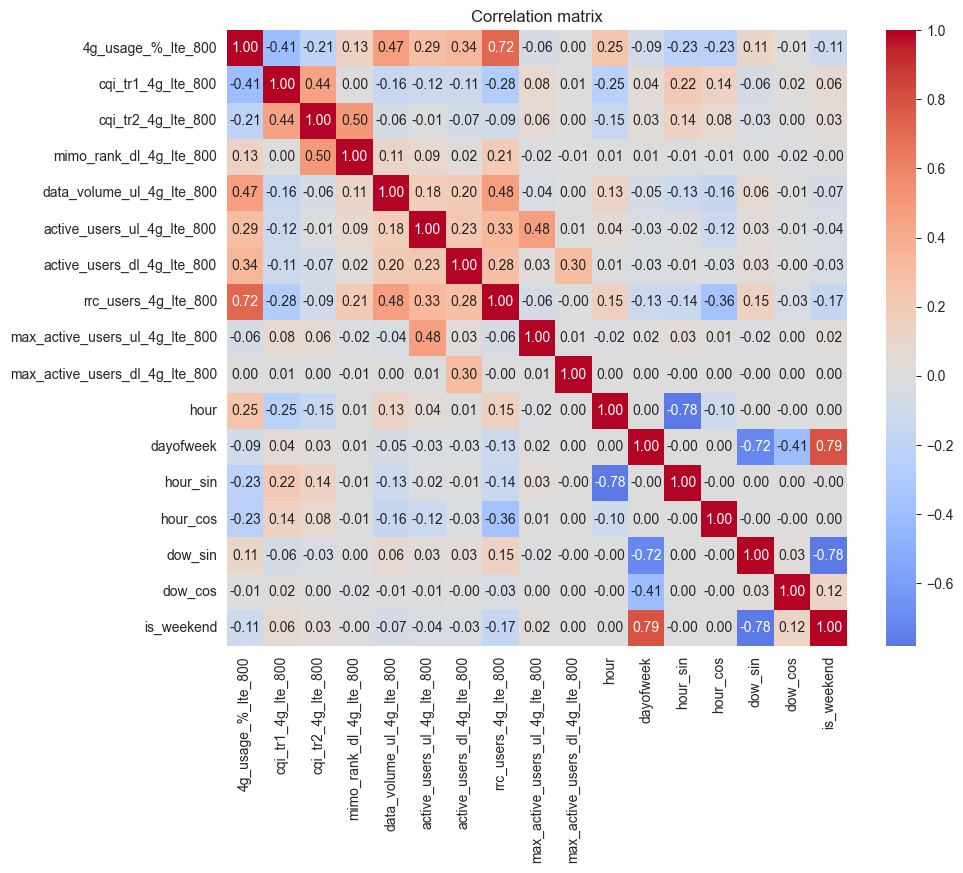

In [21]:
df_kpi.columns
kpi_cols = [
    "4g_usage_%_lte_800",
    'cqi_tr1_4g_lte_800',
    'cqi_tr2_4g_lte_800',
    'mimo_rank_dl_4g_lte_800',
    # "data_volume_dl_4g_lte_800", correlating with usage % (89%)
    "data_volume_ul_4g_lte_800",
    "active_users_ul_4g_lte_800",
    'active_users_dl_4g_lte_800',
    "rrc_users_4g_lte_800",
    "max_active_users_ul_4g_lte_800",
    "max_active_users_dl_4g_lte_800",
    'hour',
    'dayofweek',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'is_weekend'
]

# считаем корреляцию
corr_matrix = df_kpi[kpi_cols].corr()

# визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

### Examples


=== CELL: TK1KAV3 ===
Features: ['active_users_ul_4g_lte_800', 'num_neighbors', '4g_usage_%_lte_800', 'neighbor_usage_mean']
Dataset size: 2831

=== METRICS (WITH SCALE) ===

neighbor_mean_cqi_tr1_4g_lte_800:
  Mean value = 9.33
  R2         = 0.440
  MAE        = 0.481 (5.15%)
  RMSE       = 0.591 (6.33%)
  MAPE       = 5.20%

neighbor_mean_cqi_tr2_4g_lte_800:
  Mean value = 8.67
  R2         = 0.385
  MAE        = 0.408 (4.71%)
  RMSE       = 0.511 (5.90%)
  MAPE       = 4.79%

neighbor_mean_mimo_rank_dl_4g_lte_800:
  Mean value = 1.32
  R2         = 0.021
  MAE        = 0.062 (4.68%)
  RMSE       = 0.076 (5.78%)
  MAPE       = 4.69%

Next step prediction:
neighbor_mean_cqi_tr1_4g_lte_800: 9.248
neighbor_mean_cqi_tr2_4g_lte_800: 8.826
neighbor_mean_mimo_rank_dl_4g_lte_800: 1.337


C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


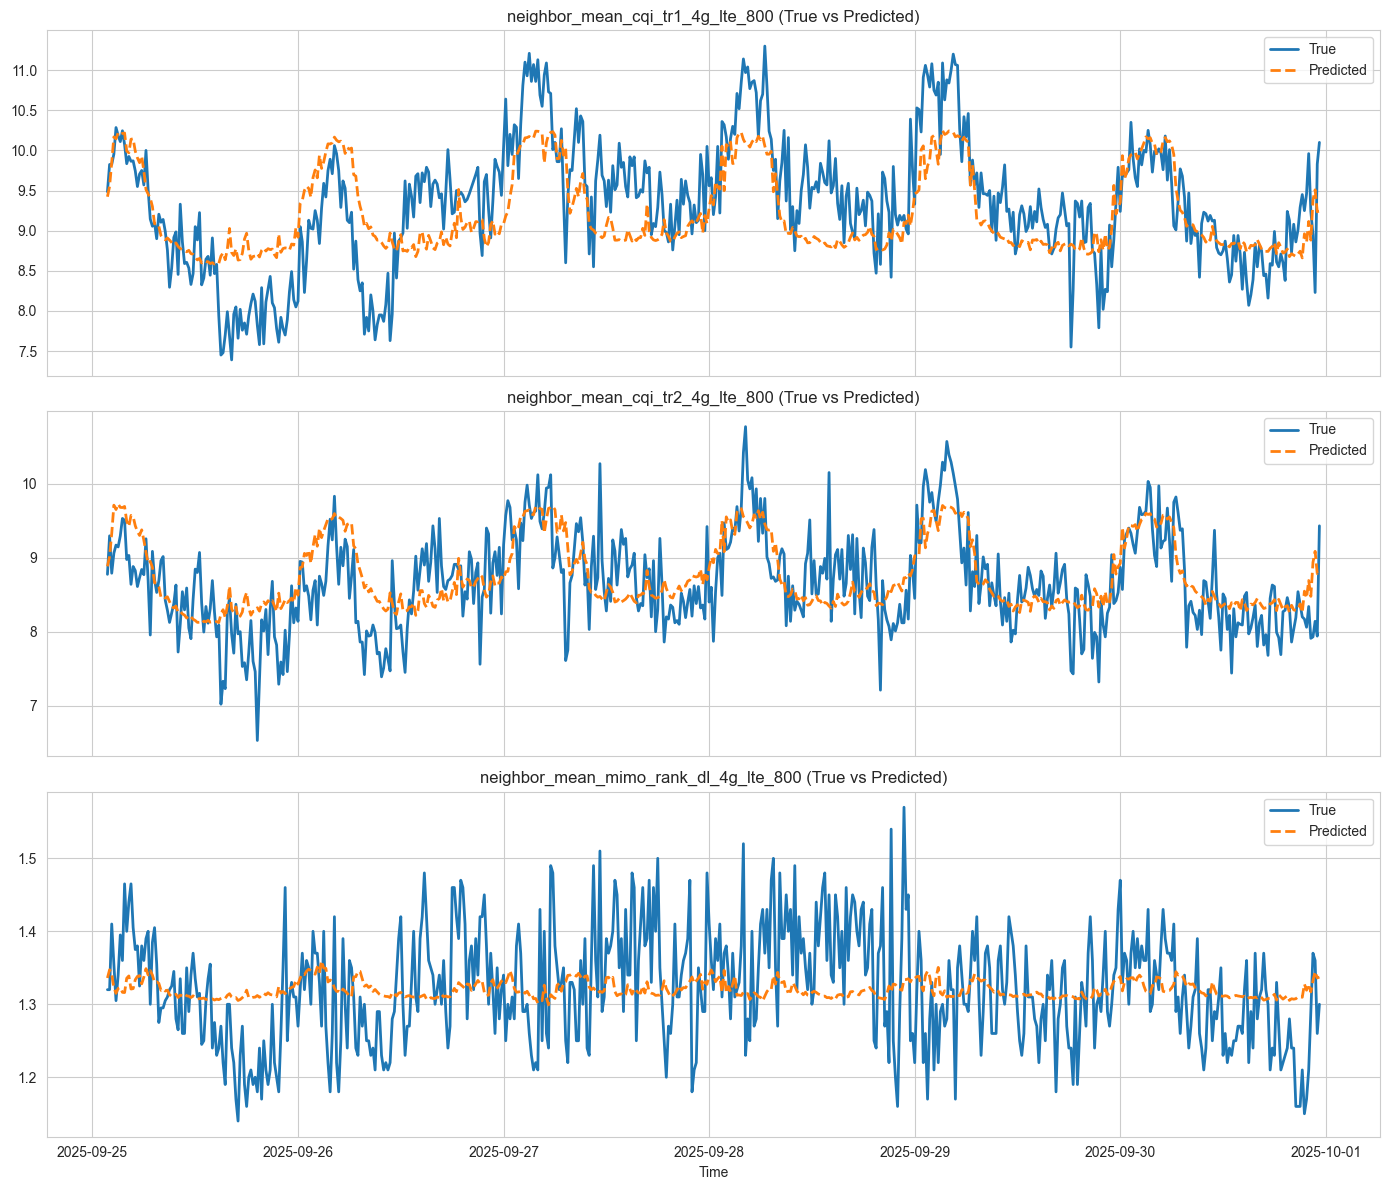

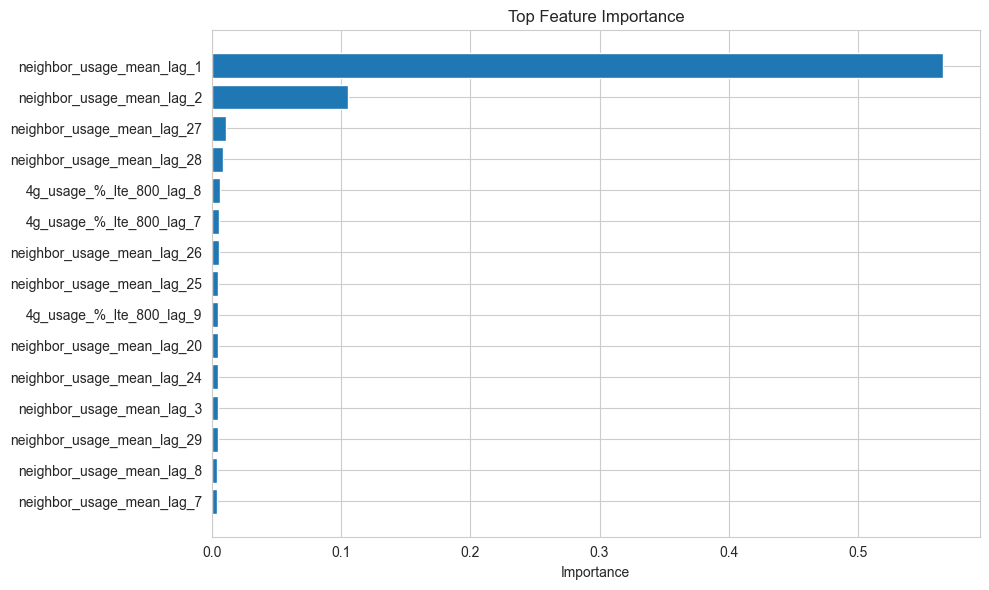

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [22]:
config = {
    "base_features": [
        "4g_usage_%_lte_800",
        "active_users_ul_4g_lte_800"
    ],
    "neighbor_usage_mean": True,
    "num_neighbors": True
}

run_ts_neighbor_model(df_kpi, neighbor_table, "TK1KAV3", config)


=== CELL: TK1KAV3 ===
Features: ['dow_sin', 'num_neighbors', 'dow_cos', 'hour', 'hour_sin', 'hour_cos', 'is_weekend', 'dayofweek', 'active_users_ul_4g_lte_800', '4g_usage_%_lte_800', 'neighbor_usage_mean']
Dataset size: 2831

=== METRICS (WITH SCALE) ===

neighbor_mean_cqi_tr1_4g_lte_800:
  Mean value = 9.33
  R2         = 0.434
  MAE        = 0.490 (5.26%)
  RMSE       = 0.594 (6.37%)
  MAPE       = 5.30%

neighbor_mean_cqi_tr2_4g_lte_800:
  Mean value = 8.67
  R2         = 0.397
  MAE        = 0.406 (4.69%)
  RMSE       = 0.506 (5.84%)
  MAPE       = 4.75%

neighbor_mean_mimo_rank_dl_4g_lte_800:
  Mean value = 1.32
  R2         = 0.027
  MAE        = 0.062 (4.68%)
  RMSE       = 0.076 (5.76%)
  MAPE       = 4.67%

Next step prediction:
neighbor_mean_cqi_tr1_4g_lte_800: 8.978
neighbor_mean_cqi_tr2_4g_lte_800: 8.520
neighbor_mean_mimo_rank_dl_4g_lte_800: 1.325


C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


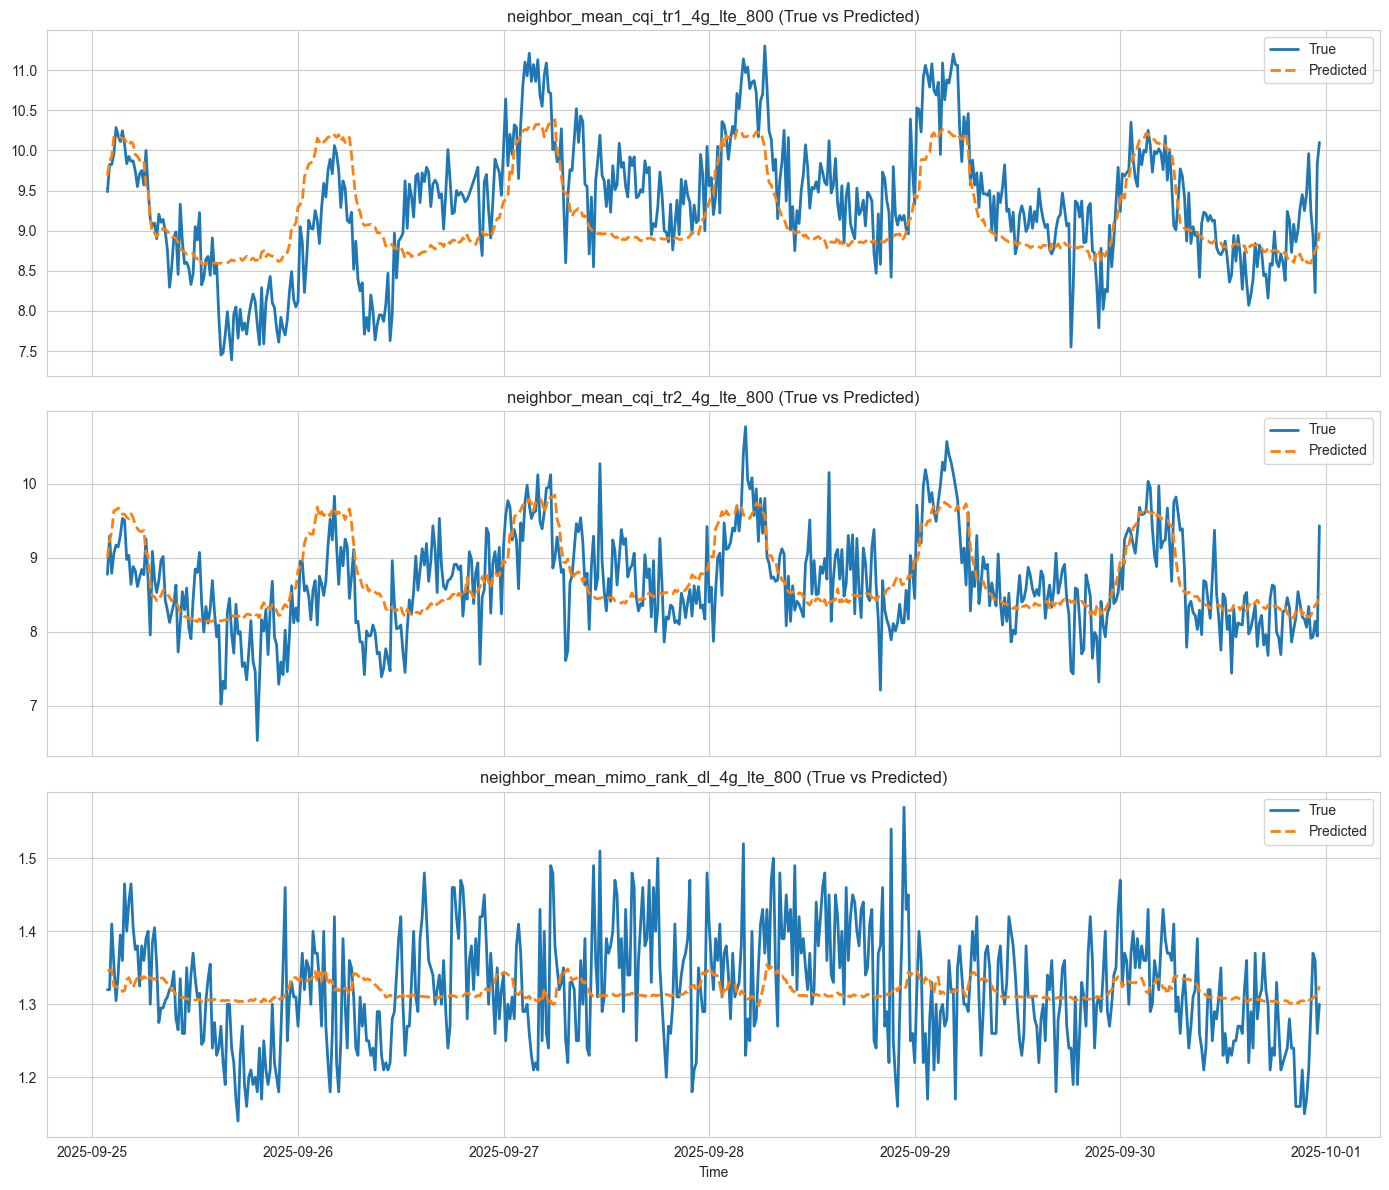

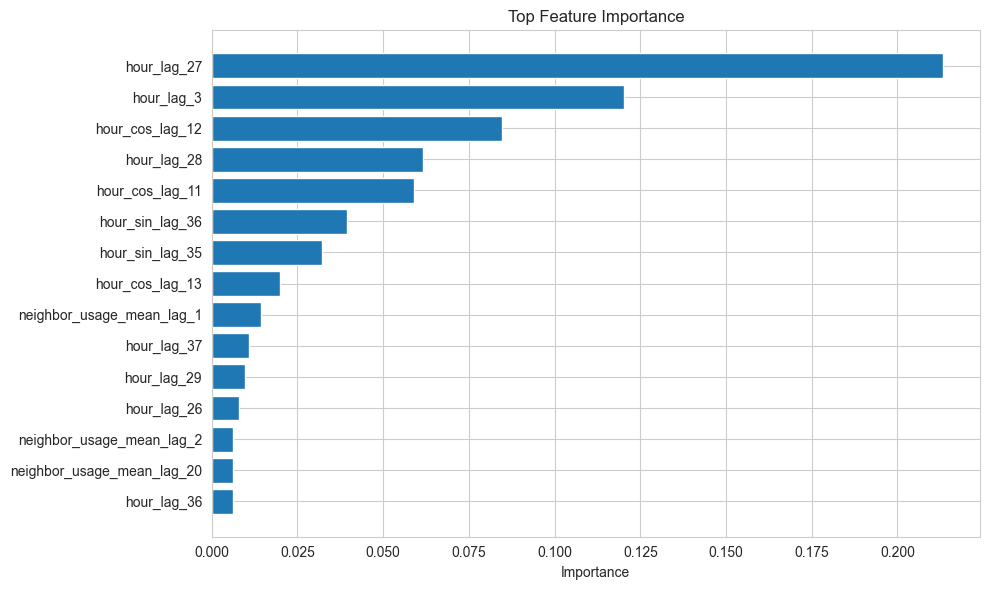

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [34]:
config = {
    "base_features": [
        "4g_usage_%_lte_800",
        "active_users_ul_4g_lte_800",
        'hour',
        'dayofweek',
        'hour_sin',
        'hour_cos',
        'dow_sin',
        'dow_cos',
        'is_weekend'
    ],
    "neighbor_usage_mean": True,
    "num_neighbors": True
}

run_ts_neighbor_model(df_kpi, neighbor_table, "TK1KAV3", config)


=== CELL: TK3KRE2 ===
Features: ['active_users_ul_4g_lte_800', 'num_neighbors', '4g_usage_%_lte_800', 'neighbor_usage_mean']
Dataset size: 2831

=== METRICS (WITH SCALE) ===

neighbor_mean_cqi_tr1_4g_lte_800:
  Mean value = 10.43
  R2         = 0.536
  MAE        = 0.509 (4.88%)
  RMSE       = 0.645 (6.18%)
  MAPE       = 4.98%

neighbor_mean_cqi_tr2_4g_lte_800:
  Mean value = 8.73
  R2         = 0.138
  MAE        = 0.669 (7.66%)
  RMSE       = 0.844 (9.66%)
  MAPE       = 7.91%

neighbor_mean_mimo_rank_dl_4g_lte_800:
  Mean value = 1.14
  R2         = -0.001
  MAE        = 0.054 (4.72%)
  RMSE       = 0.067 (5.91%)
  MAPE       = 4.67%

Next step prediction:
neighbor_mean_cqi_tr1_4g_lte_800: 9.741
neighbor_mean_cqi_tr2_4g_lte_800: 8.405
neighbor_mean_mimo_rank_dl_4g_lte_800: 1.131


C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


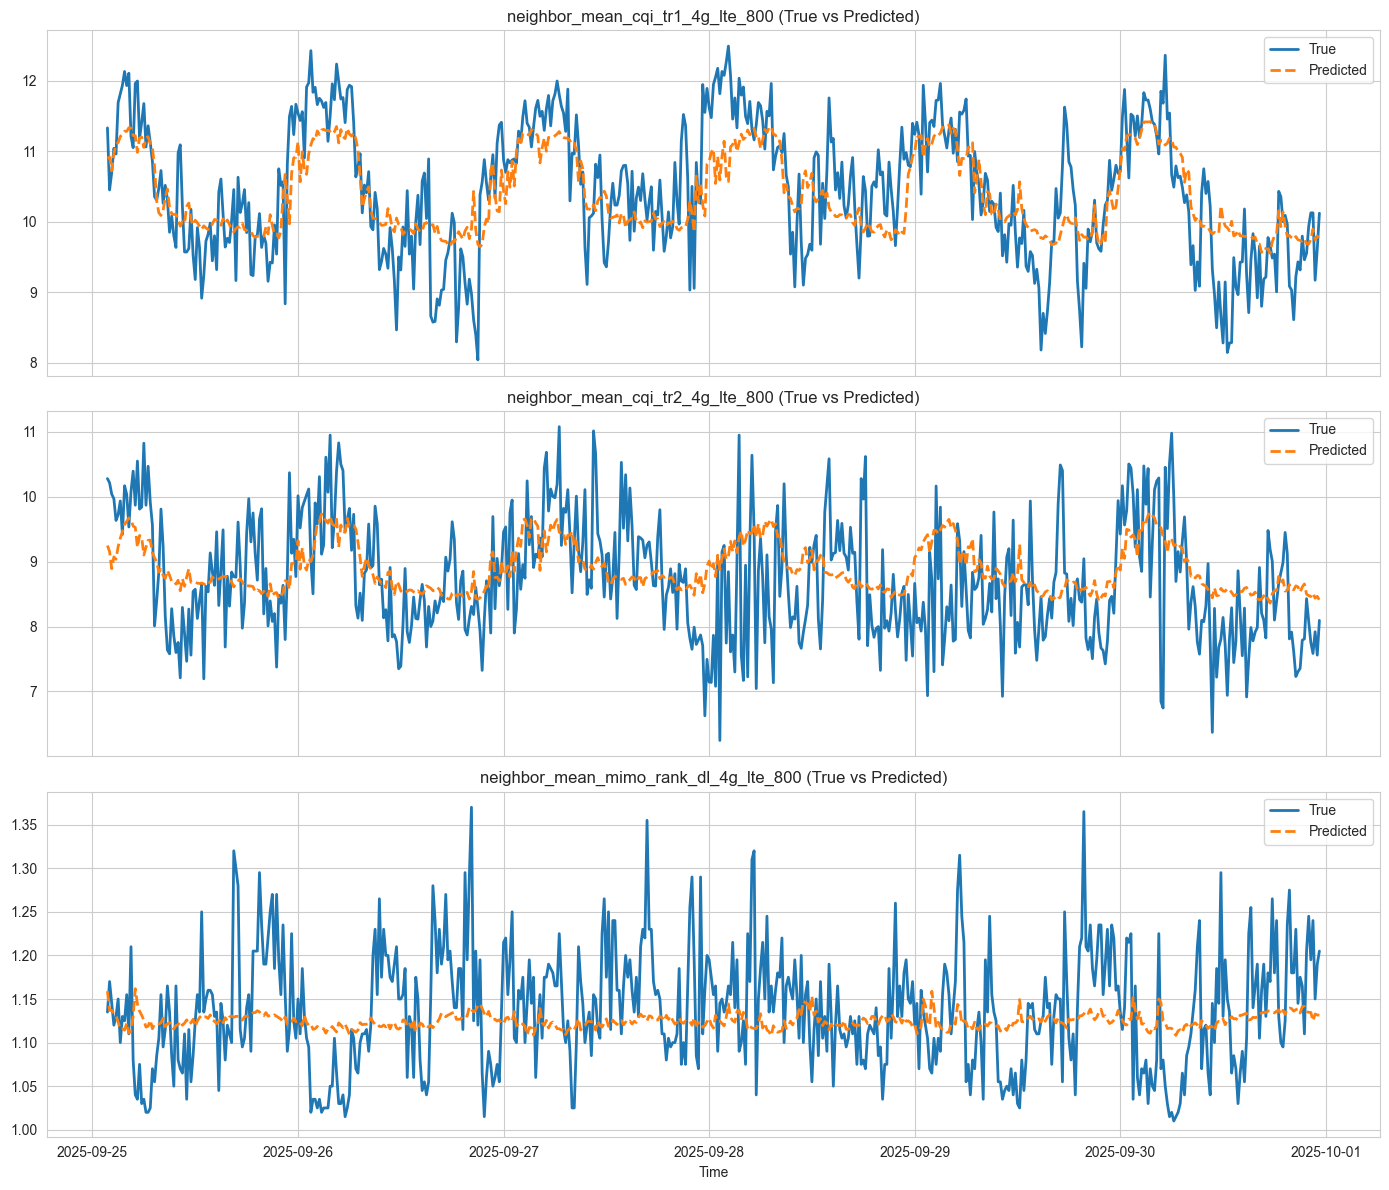

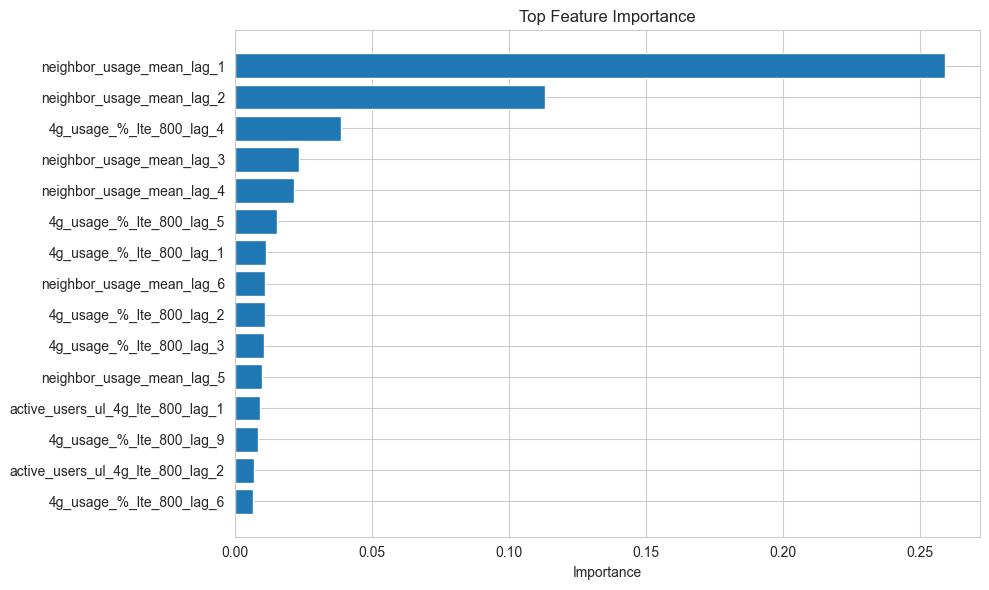

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [24]:
config = {
    "base_features": [
        "4g_usage_%_lte_800",
        "active_users_ul_4g_lte_800",
        "neighbor_usage_mean",
        "num_neighbors"
    ],
    "neighbor_usage_mean": True,
    "num_neighbors": True
}

run_ts_neighbor_model(df_kpi, neighbor_table, "TK3KRE2", config)




=== CELL: TK3KRE2 ===
Features: ['dow_sin', 'rrc_users_4g_lte_800', 'num_neighbors', 'dow_cos', 'hour', 'hour_sin', 'hour_cos', 'is_weekend', 'dayofweek', 'active_users_ul_4g_lte_800', '4g_usage_%_lte_800', 'neighbor_usage_mean']
Dataset size: 2831

=== METRICS (WITH SCALE) ===

neighbor_mean_cqi_tr1_4g_lte_800:
  Mean value = 10.43
  R2         = 0.556
  MAE        = 0.490 (4.70%)
  RMSE       = 0.630 (6.04%)
  MAPE       = 4.86%

neighbor_mean_cqi_tr2_4g_lte_800:
  Mean value = 8.73
  R2         = 0.097
  MAE        = 0.690 (7.91%)
  RMSE       = 0.864 (9.90%)
  MAPE       = 8.18%

neighbor_mean_mimo_rank_dl_4g_lte_800:
  Mean value = 1.14
  R2         = -0.022
  MAE        = 0.054 (4.74%)
  RMSE       = 0.068 (5.97%)
  MAPE       = 4.68%

Next step prediction:
neighbor_mean_cqi_tr1_4g_lte_800: 10.569
neighbor_mean_cqi_tr2_4g_lte_800: 8.576
neighbor_mean_mimo_rank_dl_4g_lte_800: 1.124


C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


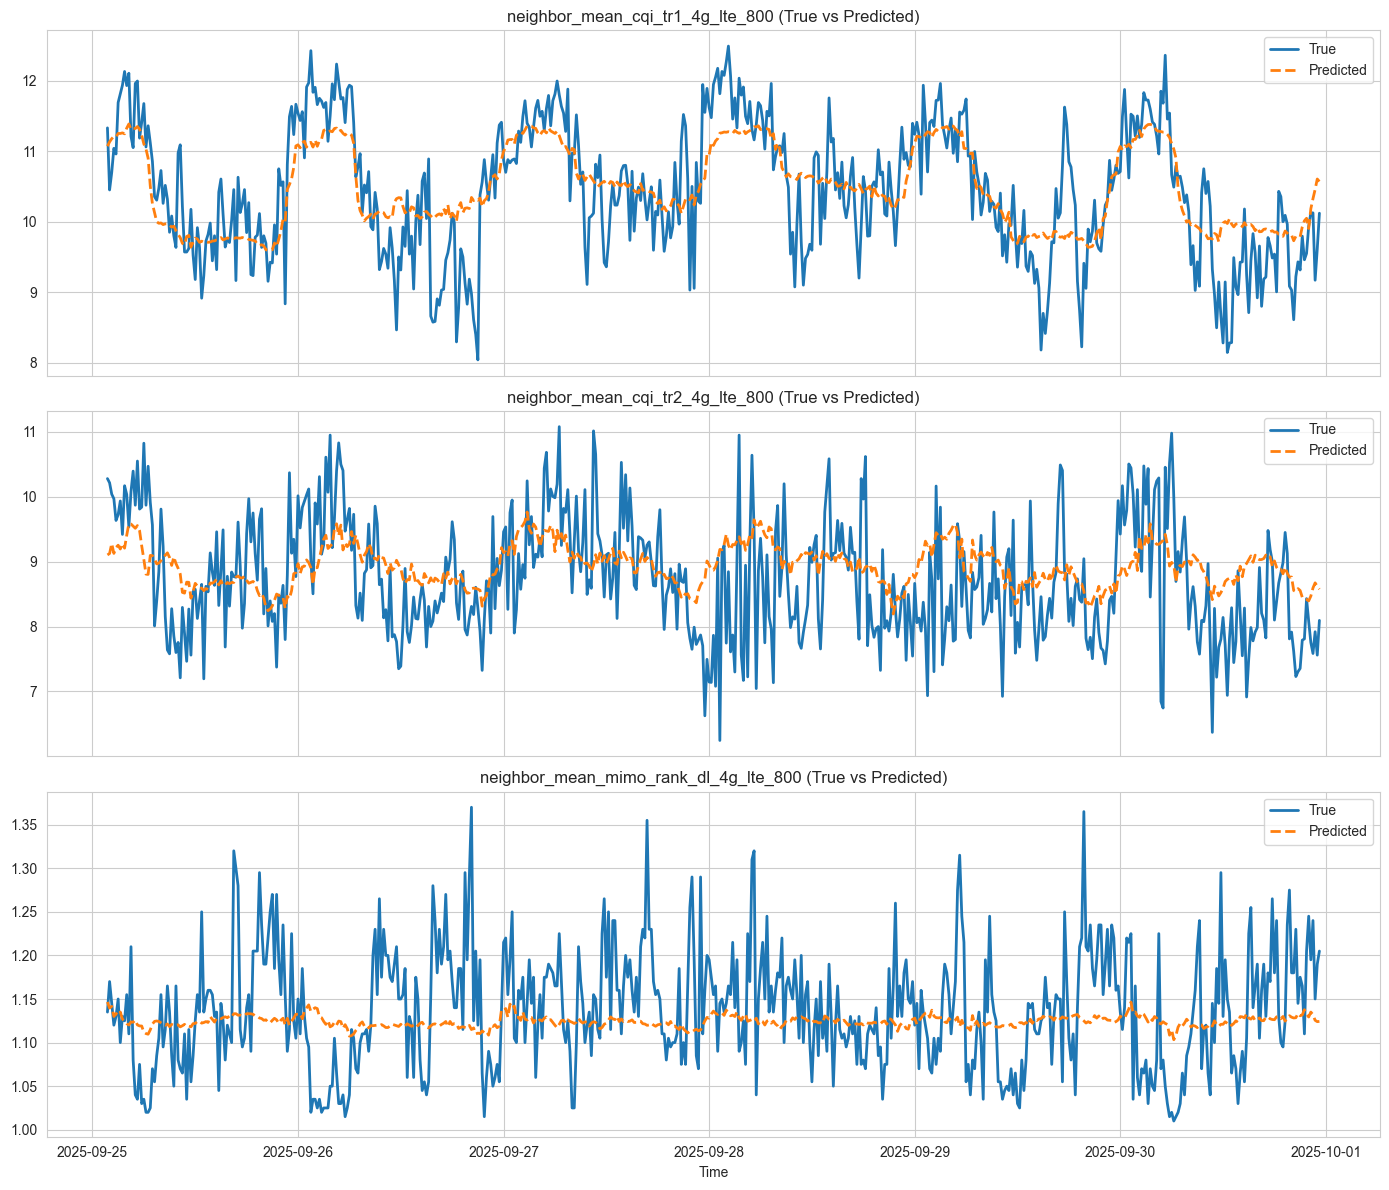

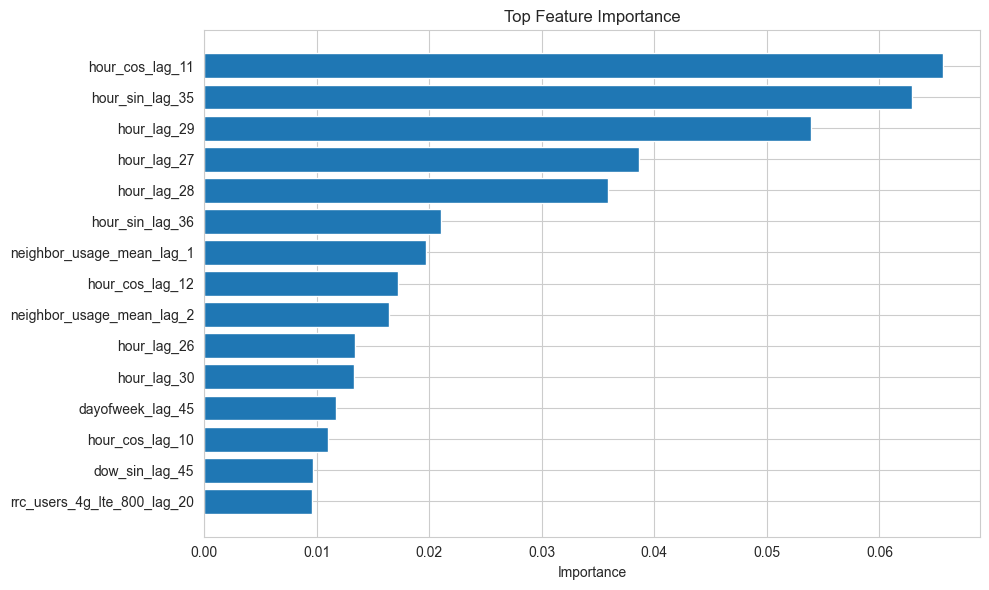

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [26]:
config = {
    "base_features": [
        "4g_usage_%_lte_800",
        "active_users_ul_4g_lte_800",
        "rrc_users_4g_lte_800",
        "neighbor_usage_mean",
        "num_neighbors",
        'hour',
        'dayofweek',
        'hour_sin',
        'hour_cos',
        'dow_sin',
        'dow_cos',
        'is_weekend'

    ],
    "neighbor_usage_mean": True,
    "num_neighbors": True
}

run_ts_neighbor_model(df_kpi, neighbor_table, "TK3KRE2", config)


# Spatial Features from the HO table
V súčasnosti môj model zohľadňuje iba samotnú bunku a jej históriu, ale v skutočnosti je sieť grafom, kde sa susedné bunky navzájom silne ovplyvňujú. Myšlienkou experimentu je pridať prvky, ktoré opisujú prostredie bunky (zaťaženie susedných buniek, preťaženie, trendy), aby model mohol vidieť širšie. Funguje to takto: agregujeme KPI susedných buniek (priemerné, maximálne, vážené hodnoty) a v priebehu času ich pridávame ako nové prvky do každej bunky. Chcem otestovať, či sa výkon modelu zlepší, ak sa zohľadnia nielen lokálne, ale aj priestorové (sieťové) závislosti.

Spatial features: ['neighbor_rrc_users_mean', 'neighbor_usage_mean', 'usage_neighbor_diff', 'neighbor_usage_trend']


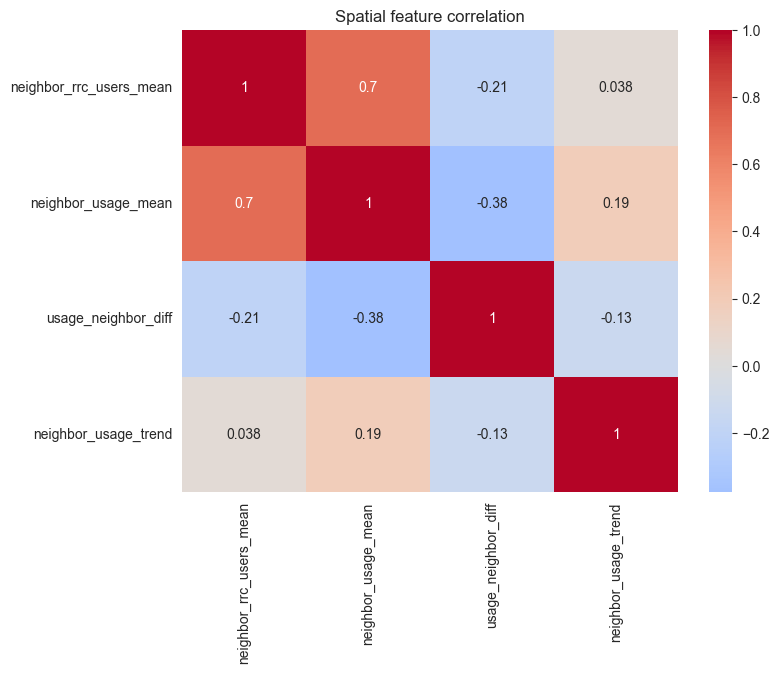

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- BUILD EDGE LIST WITH WEIGHTS ----------
edges_df = df_ho_clean.copy()
edges_df["weight"] = edges_df["ho_count"] / edges_df.groupby("source")["ho_count"].transform("sum")
edges_df = edges_df[["source", "target", "weight"]]

# ---------- PREP DATA ----------
df_kpi_grid = df_kpi.copy()
TARGET_COL = "4g_usage_lte_800"

# ---------- SPATIAL FEATURES ----------
def compute_spatial_features(df_kpi_grid, edges_df,
                             time_col="start_time", cell_col="cell"):

    kpi_cols = ["4g_usage_lte_800", "rrc_users_4g_lte_800"]

    neighbor_df = edges_df.merge(
        df_kpi_grid[[time_col, cell_col] + kpi_cols],
        left_on="target",
        right_on=cell_col,
        how="left"
    ).rename(columns={cell_col: "neighbor_cell"})

    records = []

    for (src, t), sub in neighbor_df.groupby(["source", time_col]):
        w = sub["weight"].values
        usage = sub["4g_usage_lte_800"].values
        rrc = sub["rrc_users_4g_lte_800"].values

        if len(usage) == 0 or np.sum(w) == 0:
            continue

        # weighted mean (главная spatial фича)
        usage_mean = np.sum(w * usage)

        # простой mean пользователей
        rrc_mean = np.mean(rrc)

        records.append({
            "cell": src,
            time_col: t,
            "neighbor_usage_mean": usage_mean,
            "neighbor_rrc_users_mean": rrc_mean
        })

    neighbor_feats = pd.DataFrame(records)

    # добавляем diff
    neighbor_feats = neighbor_feats.merge(
        df_kpi_grid[[time_col, cell_col, TARGET_COL]],
        on=[time_col, cell_col],
        how="left"
    )

    neighbor_feats["usage_neighbor_diff"] = (
        neighbor_feats[TARGET_COL] - neighbor_feats["neighbor_usage_mean"]
    )

    # merge обратно
    df_out = df_kpi_grid.merge(
        neighbor_feats.drop(columns=[TARGET_COL]),
        on=[time_col, cell_col],
        how="left"
    )

    return df_out


# ---------- APPLY ----------
df_kpi_grid = compute_spatial_features(df_kpi_grid, edges_df)

# ---------- TREND ----------
df_kpi_grid["neighbor_usage_trend"] = (
    df_kpi_grid
    .sort_values(["cell", "start_time"])
    .groupby("cell")["neighbor_usage_mean"]
    .diff()
)

# ---------- FINAL FEATURES ----------
SPATIAL_FEATURES = [
    "neighbor_rrc_users_mean",
    "neighbor_usage_mean",
    "usage_neighbor_diff",
    "neighbor_usage_trend"
]

print("Spatial features:", SPATIAL_FEATURES)

# ---------- CORRELATION ----------
df_spatial = df_kpi_grid[SPATIAL_FEATURES].dropna()

corr_matrix = df_spatial.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Spatial feature correlation")
plt.show()

Parameter **neighbor_usage_mean** zobrazuje celkové okolité zaťaženie, parameter **usage_neighbor_diff** zobrazuje, či je samotná bunka preťažená v porovnaní so svojimi susedmi, a parameter **neighbor_usage_trend** zobrazuje, či okolité zaťaženie rastie alebo klesá.

Parametre **max, sum, std a strongest** som odstránilа, pretože sú buď zašumené, alebo vysoko korelujú s priemerom a nepridávajú žiadne nové informácie.


=== CELL: TK3KRE2 ===
Features: ['num_neighbors', 'neighbor_rrc_users_mean', 'neighbor_usage_trend', 'usage_neighbor_diff', 'active_users_ul_4g_lte_800', '4g_usage_%_lte_800', 'neighbor_usage_mean']
Dataset size: 2830

=== METRICS (WITH SCALE) ===

neighbor_mean_cqi_tr1_4g_lte_800:
  Mean value = 10.43
  R2         = 0.563
  MAE        = 0.495 (4.74%)
  RMSE       = 0.626 (6.00%)
  MAPE       = 4.81%

neighbor_mean_cqi_tr2_4g_lte_800:
  Mean value = 8.73
  R2         = 0.216
  MAE        = 0.635 (7.28%)
  RMSE       = 0.804 (9.21%)
  MAPE       = 7.49%

neighbor_mean_mimo_rank_dl_4g_lte_800:
  Mean value = 1.14
  R2         = -0.009
  MAE        = 0.054 (4.75%)
  RMSE       = 0.068 (5.94%)
  MAPE       = 4.69%

Next step prediction:
neighbor_mean_cqi_tr1_4g_lte_800: 10.003
neighbor_mean_cqi_tr2_4g_lte_800: 8.451
neighbor_mean_mimo_rank_dl_4g_lte_800: 1.124


C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


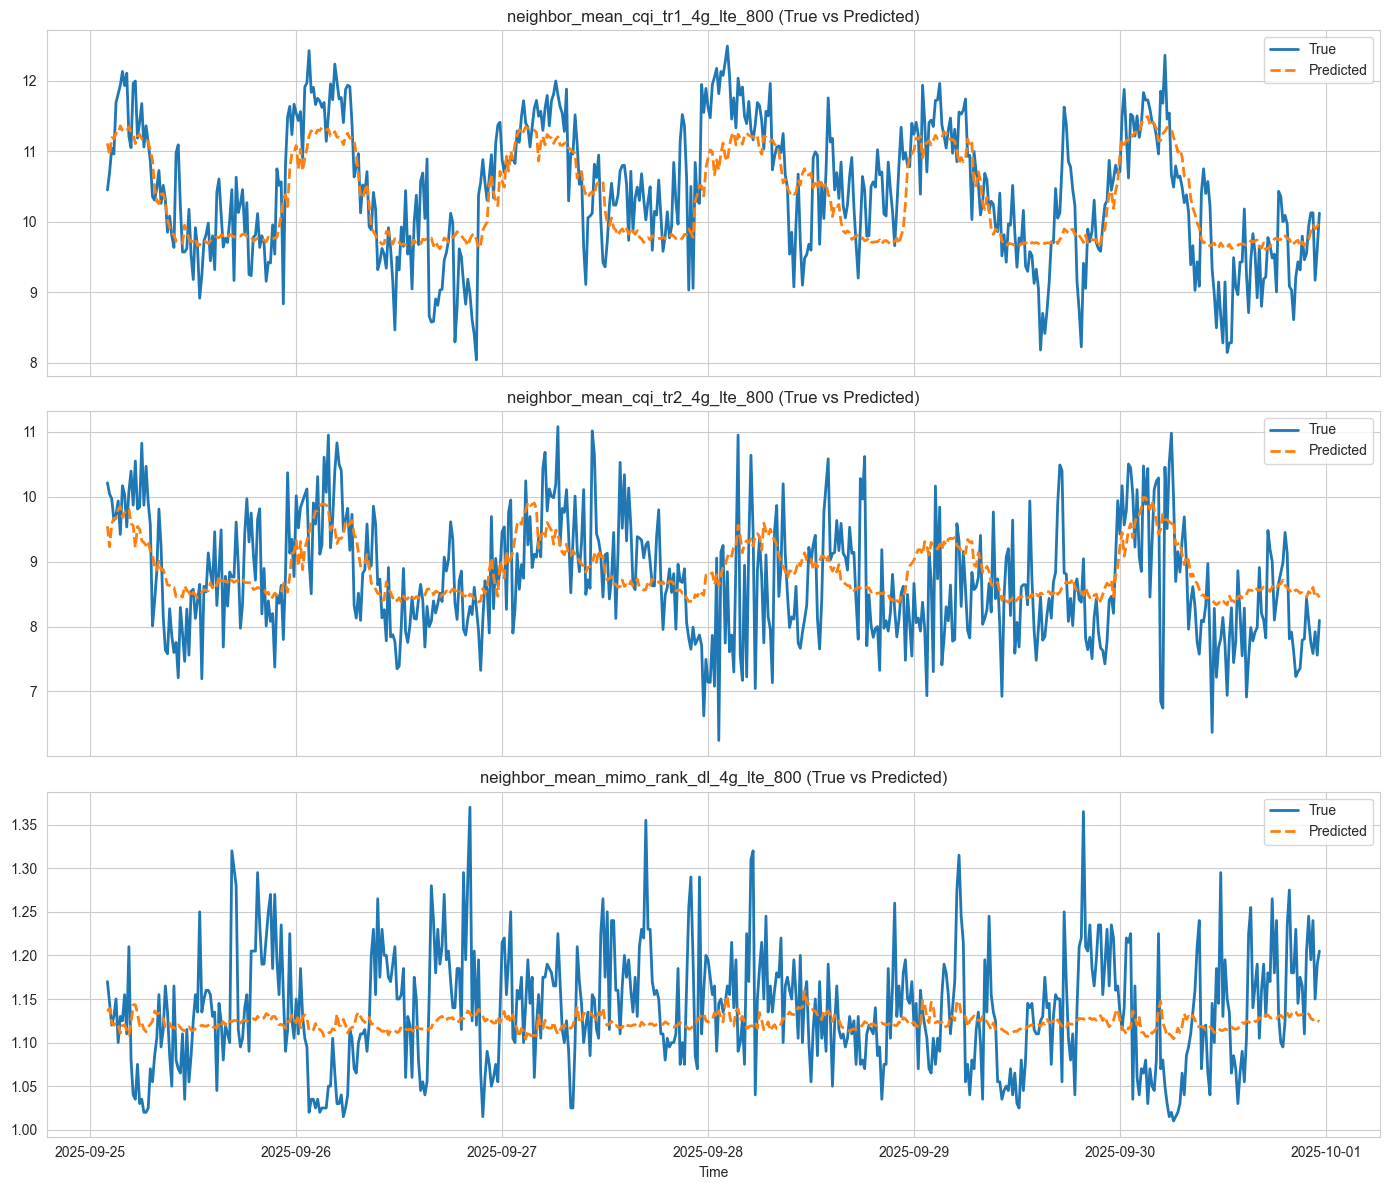

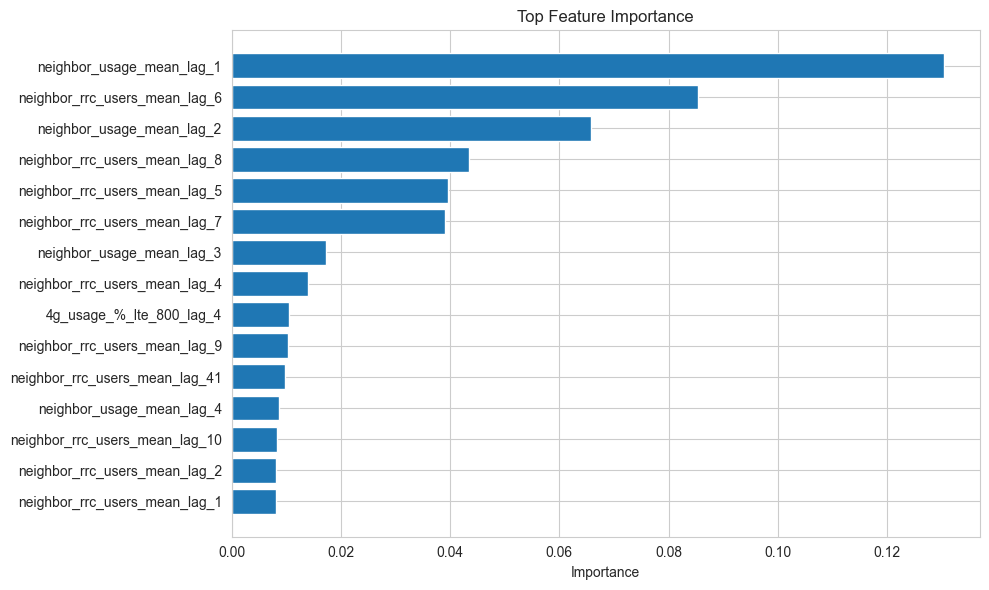

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [33]:
config = {
    "base_features": [
        "4g_usage_%_lte_800",
        "active_users_ul_4g_lte_800",
        "neighbor_usage_mean",
        "num_neighbors",
        "neighbor_rrc_users_mean",
        "neighbor_usage_mean",
        "usage_neighbor_diff",
        "neighbor_usage_trend"

    ],
    "neighbor_usage_mean": True,
    "num_neighbors": True
}

run_ts_neighbor_model(df_kpi_grid, neighbor_table, "TK3KRE2", config)

| CELL    | Features                                                                                                                                                                                              | R² (cq1, cq2, mimo)  | MAE (cq1, cq2, mimo) | RMSE (cq1, cq2, mimo) | MAPE (cq1, cq2, mimo) |
| ------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------- | -------------------- | --------------------- | --------------------- |
| TK1KAV3 | ['active_users_ul_4g_lte_800', 'num_neighbors', '4g_usage_%_lte_800', 'neighbor_usage_mean']                                                                                                          | 0.440, 0.385, 0.021  | 0.481, 0.408, 0.062  | 0.591, 0.511, 0.076   | 5.20%, 4.79%, 4.69%   |
| TK1KAV3 | ['dow_sin', 'num_neighbors', 'dow_cos', 'hour', 'hour_sin', 'hour_cos', 'is_weekend', 'dayofweek', 'active_users_ul_4g_lte_800', '4g_usage_%_lte_800', 'neighbor_usage_mean']                         | 0.434, 0.397, 0.027  | 0.490, 0.406, 0.062  | 0.594, 0.506, 0.076   | 5.30%, 4.75%, 4.67%   |
| TK3KRE2 | ['active_users_ul_4g_lte_800', 'num_neighbors', '4g_usage_%_lte_800', 'neighbor_usage_mean']                                                                                                          | 0.536, 0.138, -0.001 | 0.509, 0.669, 0.054  | 0.645, 0.844, 0.067   | 4.98%, 7.91%, 4.67%   |
| TK3KRE2 | ['dow_sin', 'rrc_users_4g_lte_800', 'num_neighbors', 'dow_cos', 'hour', 'hour_sin', 'hour_cos', 'is_weekend', 'dayofweek', 'active_users_ul_4g_lte_800', '4g_usage_%_lte_800', 'neighbor_usage_mean'] | 0.556, 0.097, -0.022 | 0.490, 0.690, 0.054  | 0.630, 0.864, 0.068   | 4.86%, 8.18%, 4.68%   |
| TK3KRE2 | ['num_neighbors', 'neighbor_rrc_users_mean', 'neighbor_usage_trend', 'usage_neighbor_diff', 'active_users_ul_4g_lte_800', '4g_usage_%_lte_800', 'neighbor_usage_mean']                                | 0.563, 0.216, -0.009 | 0.495, 0.635, 0.054  | 0.626, 0.804, 0.068   | 4.81%, 7.49%, 4.69%   |

В первой таблице видно, что базовая модель уже даёт неплохой результат для CQI TR1 (R² ~0.44–0.54), но значительно хуже для CQI TR2 и почти не работает для MIMO. Добавление time features практически не улучшает модель: изменения минимальны и нестабильны, иногда даже ухудшают результат, что говорит о слабой временной зависимости. В то же время spatial features дают наибольший прирост, особенно для CQI TR2 (рост R² с ~0.14 до ~0.22), что подтверждает важность учета окружения клетки.


Во второй таблице видно, что добавление взвешенных (weighted) KPI соседей почти не улучшает модель, а иногда даже немного ухудшает её (например, падение R² для CQI TR1 в TK3KRE2). Это означает, что сама идея weighting по HO не даёт значимой дополнительной информации по сравнению с обычным средним. Добавление большого количества признаков (time + weighted + KPI) приводит к переусложнению модели, что ухудшает результаты (особенно для CQI TR2). В итоге простые признаки оказываются более устойчивыми и эффективными, чем сложные комбинации.


Короче, Spatial features дают реальный и стабильный прирост качества, тогда как weighted подход почти не приносит пользы и усложняет модель без выигрыша. Time features оказываются наименее полезными и могут даже вносить шум. Но это наверное из-за того, что история моя всего лишь в 12 часов.

